# Ali Abdullah Ahmad
# CWID - 20031246

In [130]:
import pandas as pd
import numpy as np

a. Load the provided data - autompg.csv. The data contains seven columns. This data set can be
used for both classification and regression problems

In [131]:
df = pd.read_csv('D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS559_Applications_of_ML/HW/hw5/autompg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


b. [10 pts] Transform mpg into an ordinal categorical feature with three values [good (2), average
(1), bad (0)] by calculating the quantiles using numpy.quantile. For other continuous columns,
convert to four-valued ordinal categorical features as (4) - high, (3) - good, (2) - okay, (1) - poor.

In [132]:
# Transform 'mpg' into an ordinal categorical feature
mpg_quantiles = np.quantile(df['mpg'], [0.33, 0.66])
df['mpg_category'] = pd.cut(df['mpg'], bins=[-np.inf, mpg_quantiles[0], mpg_quantiles[1], np.inf], labels=[0, 1, 2])

# Function to convert continuous columns into four-valued ordinal categorical features
def convert_to_ordinal(column):
    quantiles = np.quantile(column.dropna(), [0.25, 0.5, 0.75])
    return pd.cut(column, bins=[-np.inf, quantiles[0], quantiles[1], quantiles[2], np.inf], labels=[1, 2, 3, 4])

# Apply the function to other continuous columns
continuous_columns = ['displacement', 'horsepower', 'weight', 'acceleration']
for col in continuous_columns:
    df[f'{col}_category'] = convert_to_ordinal(df[col])

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year,mpg_category,displacement_category,horsepower_category,weight_category,acceleration_category
0,18.0,8,307.0,130.0,3504,12.0,70,0,4,4,3,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,4,4,4,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,4,4,3,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,4,4,3,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,4,4,3,1


c. [15 pts] Implement a myKmeans(X, k, max iter) algorithm as a function (not a class) using
only NumPy. The parameter X is the data, k is the number of clusters, and max iter is the
maximum number of iterations. The function returns the final cluster labels, the final centroids of
the clusters, and the final inertia, which is defined as the sum of the squared distance of each data
point to its cluster centroid.

In [133]:
def myKmeans(X, k, max_iter):
    # Randomly initialize centroids by selecting k random points from X
    np.random.seed(42)  # For reproducibility
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for _ in range(max_iter):
        # Compute distances from each point to each centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        
        # Assign each point to the nearest centroid
        labels = np.argmin(distances, axis=1)
        
        # Compute new centroids as the mean of points in each cluster
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # Check for convergence (if centroids do not change)
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    # Compute final inertia
    inertia = np.sum((X - centroids[labels])**2)
    
    return labels, centroids, inertia

d. [15 pts] Determine the appropriate k value of the new data set using myKmeans. Show that the
inertia converges as k increases.

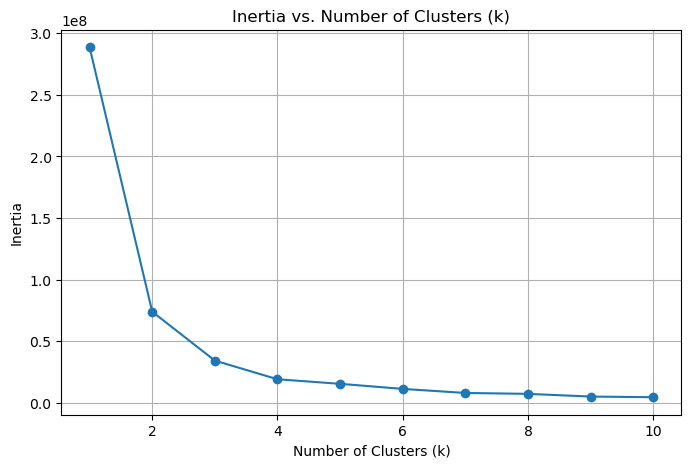

In [134]:
import matplotlib.pyplot as plt

# Prepare the data for clustering (use only numerical columns)
X = df[['displacement', 'horsepower', 'weight', 'acceleration']].dropna().values

# Run myKmeans for different values of k and store the inertia
k_values = range(1, 11)
inertia_values = []

for k in k_values:
    _, _, inertia = myKmeans(X, k, max_iter=100)
    inertia_values.append(inertia)

# Plot the inertia values
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Inertia vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

e. [20 pts] Using the results of myKmeans with the best k value from (d), build a linear classification
model using Scikit-learn that predicts the cluster label. Split the data into training and test sets
by 8 to 2, and report the accuracy for both train and test.

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use the best k value from (d)
best_k = k_values[3] # 3 from elbow method

# Run myKmeans to get the cluster labels
labels, centroids, _ = myKmeans(X, best_k, max_iter=1000)

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# Build and train the linear classification model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

# Predict the cluster labels for train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate and report the accuracy for both train and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 1.00
Test Accuracy: 0.97


### 2 Dimensionality Reduction [40 pts]

a. Load the provided data - pca data.csv.

In [136]:
df_pca = pd.read_csv('D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS559_Applications_of_ML/HW/hw5/pca_data.csv')
df_pca.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


b. [15 pts] Study the data and hypothesize the appropriate number of dimensions (n) that the data
can be reduced to. Use statistics and visualizations to support your answer.

Data Types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Descriptive Statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.60000

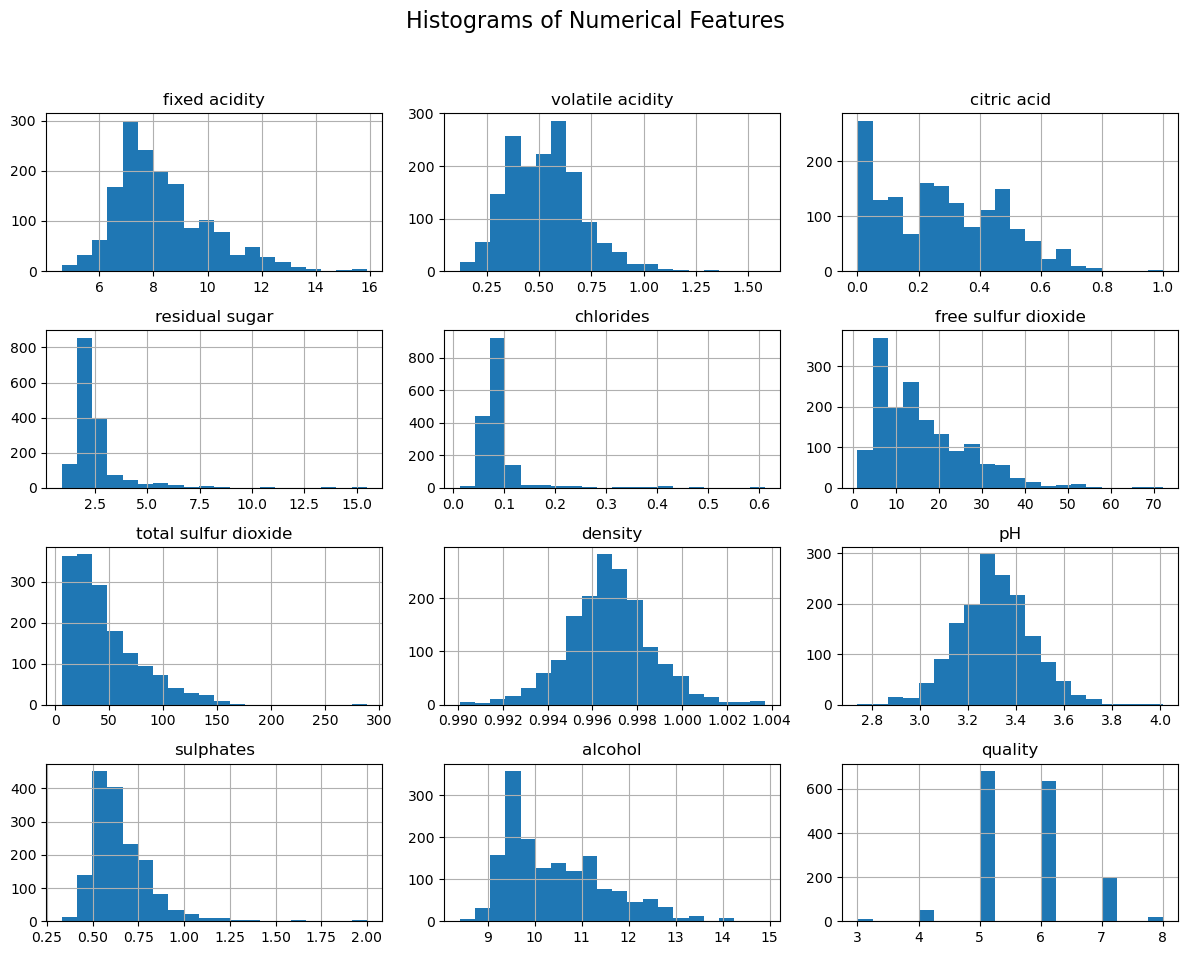

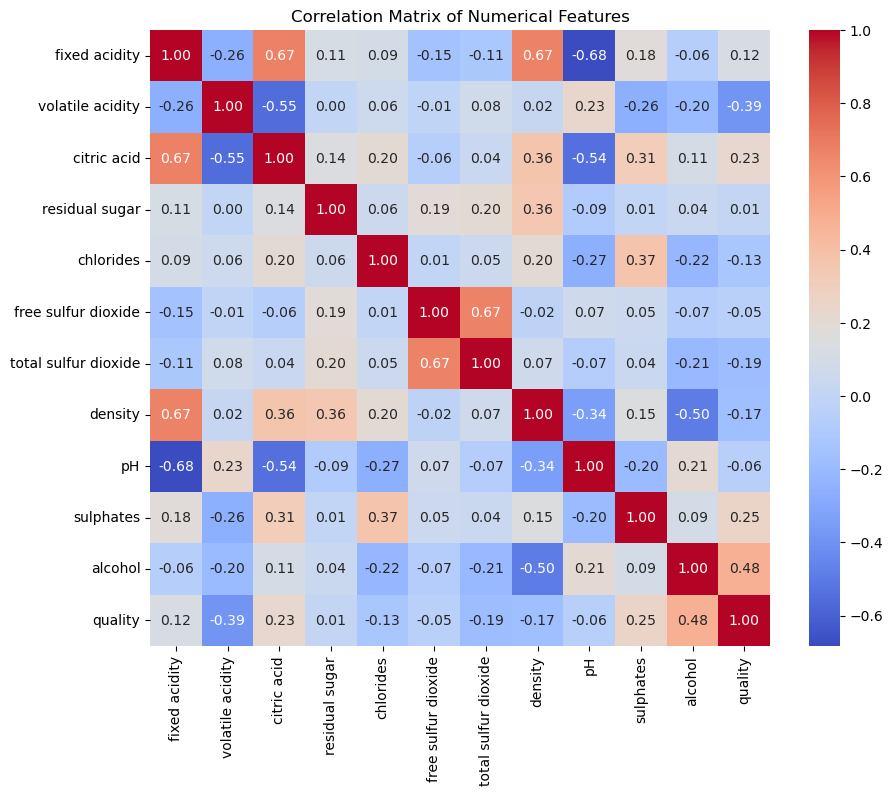

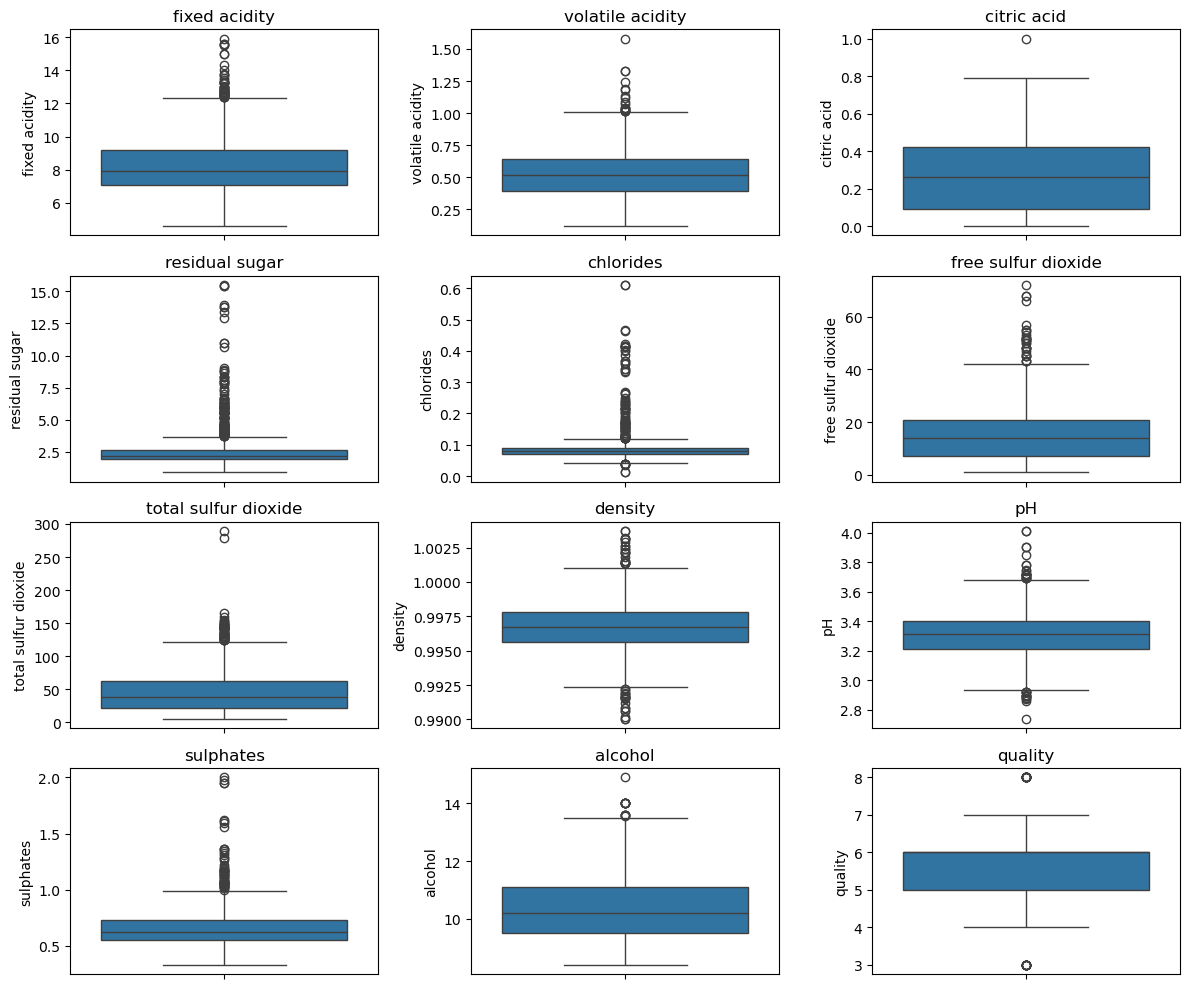

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine data types
print("Data Types:\n", df_pca.dtypes)

# 2. Descriptive statistics
print("\nDescriptive Statistics:\n", df_pca.describe())

# 3. Missing values
print("\nMissing Values:\n", df_pca.isnull().sum())

# 4. Visualize distributions
df_pca.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# 5. Correlation matrix
correlation_matrix = df_pca.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# 6. Potential outliers (box plots)
plt.figure(figsize=(12, 10))
for i, col in enumerate(df_pca.select_dtypes(include=['number']).columns):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df_pca[col])
    plt.title(col)
plt.tight_layout()
plt.show()

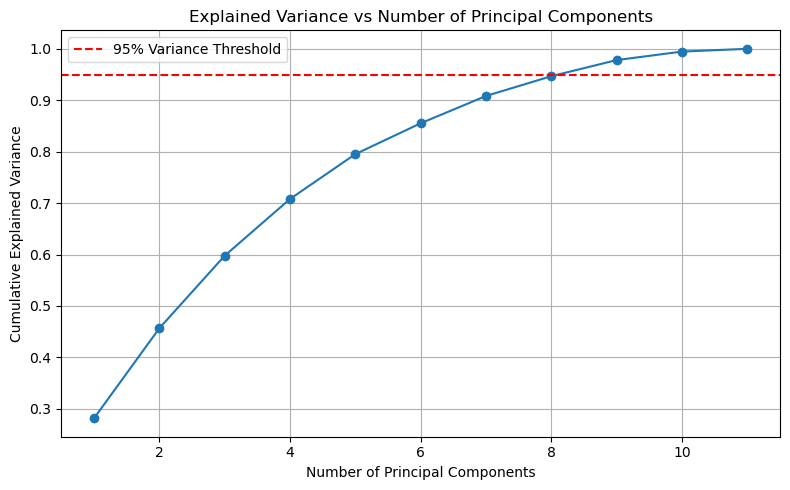

The optimal number of dimensions is: 8


In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df_pca = pd.read_csv("pca_data.csv")  # adjust path if necessary

# Separate features and target
X = df_pca.drop(columns=["quality"])  # assuming 'quality' is the target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Principal Components')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# Calculate the cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Hypothesis: The number of dimensions where cumulative variance exceeds 95%
optimal_dimensions = np.argmax(cumulative_variance_ratio >= 0.95) 
print(f"The optimal number of dimensions is: {optimal_dimensions}")

c. [15 pts] Implement a function myPCA(X, n) (no class) that takes the data X and n is the number
of components found in b. The function will return the principal components.

In [139]:
def myPCA(X, n):
    """
    Perform Principal Component Analysis (PCA) on the given data.

    Parameters:
    X (numpy.ndarray): The input data matrix (rows are samples, columns are features).
    n (int): The number of principal components to retain.

    Returns:
    numpy.ndarray: The transformed data with n principal components.
    """
    # Step 1: Center the data by subtracting the mean of each feature
    X_centered = X - np.mean(X, axis=0)
    
    # Step 2: Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: Compute the eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    
    # Step 4: Sort the eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    
    # Step 5: Select the top n eigenvectors
    principal_components = eigenvectors[:, :n]
    
    # Step 6: Project the data onto the top n principal components
    X_transformed = np.dot(X_centered, principal_components)
    
    return X_transformed

d. [10 pts] Perform myPCA on the data and compare the result with Scikit-learn PCA

In [140]:
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_pca_standardized = scaler.fit_transform(X_pca)

# Perform PCA on the standardized data
X_myPCA = myPCA(X_pca_standardized, optimal_dimensions)
X_sklearnPCA = pca.fit_transform(X_pca_standardized)[:, :optimal_dimensions]

# Compare the results
print("First 5 rows of myPCA result:")
print(X_myPCA[:5])

print("\nFirst 5 rows of Scikit-learn PCA result:")
print(X_sklearnPCA[:5])

# Check if the absolute values of the results are approximately equal
comparison = np.allclose(np.abs(X_myPCA), np.abs(X_sklearnPCA), atol=1e-5)
print(f"Are the absolute values of myPCA and Scikit-learn PCA approximately equal? {comparison}")

First 5 rows of myPCA result:
[[-1.85864877e-01 -8.97322649e-02 -4.58155858e-01 -4.67835657e-01
  -8.72810946e-01  1.52365584e+00  5.90314345e-01  6.94245798e-01]
 [-6.74265740e-01  3.25038940e-01  7.29988797e-02  1.15163457e+00
  -2.25376213e-01 -4.43766792e-01  1.12149085e-01  2.02570391e+00]
 [-8.00985326e-01  1.44619419e-03  2.08829331e-01  3.84424034e-01
  -2.89775096e-01  8.79884117e-02  2.24244403e-01  1.41906965e+00]
 [ 1.23210419e+00  3.01684404e-01 -2.03539245e-01 -2.03091065e+00
   4.65900523e-01 -8.94767689e-01  5.04589974e-01 -2.23781377e-01]
 [-1.85864877e-01 -8.97322649e-02 -4.58155858e-01 -4.67835657e-01
  -8.72810946e-01  1.52365584e+00  5.90314345e-01  6.94245798e-01]]

First 5 rows of Scikit-learn PCA result:
[[-0.0807962  -0.26689935  0.35587251 -0.19060408 -0.70495601  1.29329321
   0.20860368 -1.38386042]
 [-0.92879973  0.49453753  0.57236243  0.03911349 -0.36811243 -1.79668449
  -0.8143656  -1.4551736 ]
 [-0.84740712  0.03207208  0.05590911 -0.15852633 -0.4014650